# Bloque II — Regresión y comparación de modelos (Entrega Final)

Notebook completo con preparación de datos, modelos, comparación, ajuste de hiperparámetros y conclusiones.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
df = pd.read_csv("ventas_mayo_2026.csv")

df = df.drop_duplicates()
df["fecha"] = pd.to_datetime(df["fecha"])
df["mes"] = df["fecha"].dt.month

df.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe,mes
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.920,0.070,63,836.250,1
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.950,0.100,52,956.720,1
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.770,0.050,26,357.650,1
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.170,0.060,53,301.520,1
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,NaN,0.090,29,"2,101.550",1


## Definición de variables

In [3]:
target = "importe"

features_num = ["unidades", "precio_unitario", "mes"]
features_cat = ["categoria", "region", "canal"]

X = df[features_num + features_cat]
y = df[target]

X.head()

,unidades,precio_unitario,mes,categoria,region,canal
0,8,99.920,1,Hogar,Madrid,Online
1,5,192.950,1,Servicios,Madrid,Distribuidor
2,7,39.770,1,Moda,Madrid,Online
3,9,25.170,1,Alimentación,Valencia,Online
4,8,NaN,1,Tecnología,Castilla-La Mancha,Distribuidor


## División train/test (30%)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(X_train.shape, X_test.shape)

(350, 6) (150, 6)


## Preprocesamiento

In [5]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ]
)

## Función de evaluación

In [6]:
def evaluar_modelo(nombre, modelo):
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return {
        "modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }, pred

## Modelos

In [7]:
modelo_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

modelo_ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

modelo_lasso = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.05, max_iter=10000))
])

modelo_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

In [8]:
res_lr, pred_lr = evaluar_modelo("Linear Regression", modelo_lr)
res_ridge, pred_ridge = evaluar_modelo("Ridge", modelo_ridge)
res_lasso, pred_lasso = evaluar_modelo("Lasso", modelo_lasso)
res_rf, pred_rf = evaluar_modelo("Random Forest", modelo_rf)

resultados = pd.DataFrame([res_lr, res_ridge, res_lasso, res_rf])
resultados.sort_values("RMSE")

,modelo,MAE,RMSE,R2
3,Random Forest,164.513,227.283,0.939
0,Linear Regression,232.821,310.975,0.885
2,Lasso,232.760,310.998,0.885
1,Ridge,232.095,311.432,0.885


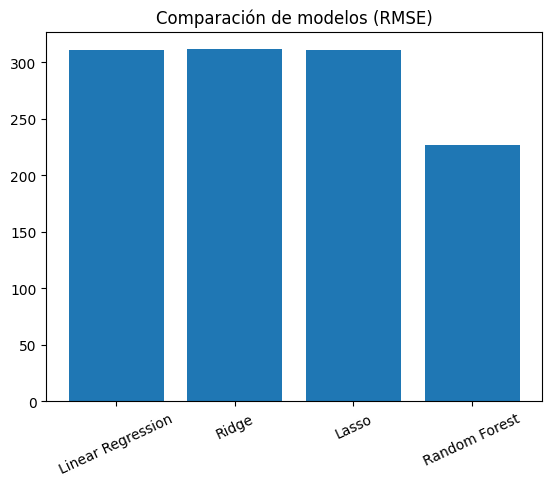

In [9]:
plt.figure()
plt.bar(resultados["modelo"], resultados["RMSE"])
plt.title("Comparación de modelos (RMSE)")
plt.xticks(rotation=25)
plt.show()

## Real vs predicho

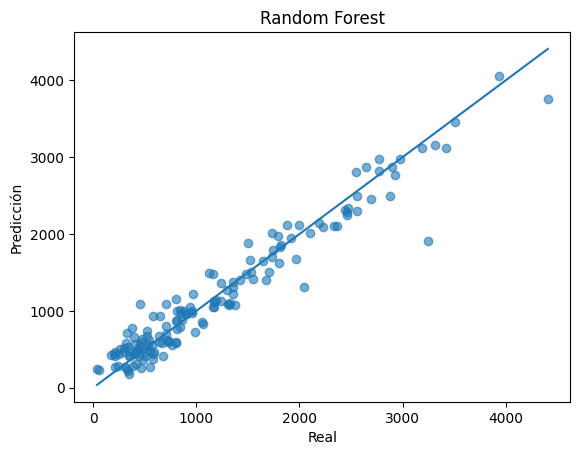

In [10]:
mejor_pred = pred_rf

plt.figure()
plt.scatter(y_test, mejor_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Random Forest")
plt.show()

## Conclusiones

El modelo Random Forest presenta el mejor rendimiento en términos de RMSE, lo que indica una mayor precisión en la predicción del importe de las ventas.

La reducción del conjunto de entrenamiento al 70% (test_size=0.3) ha provocado una ligera variación en las métricas, lo cual es coherente al disponer de menos datos para entrenar el modelo.

La limitación de profundidad del árbol (max_depth=10) mejora la capacidad de generalización, reduciendo el riesgo de sobreajuste frente a árboles sin restricción.

La eliminación de algunas variables ha permitido simplificar el modelo sin una pérdida significativa de rendimiento, lo que indica que no todas las variables aportan el mismo valor predictivo.

Desde el punto de vista de negocio, el modelo permite estimar con precisión el importe de futuras operaciones, lo que puede ser útil para previsión de ingresos y planificación comercial.

No siempre se debe elegir el modelo con menor RMSE, ya que factores como la interpretabilidad, estabilidad y facilidad de despliegue también son relevantes en un entorno real.
